In [ ]:

# MODÜL B — AKADEMİK MAKALE ATIF SAYISI TAHMİNİ (REGRESYON)

# Amaç: cited_by_count regresyonu; içerikten + bibliyometrik özelliklerden
# atıf sayısı tahmini. Çarpık dağılım için log1p dönüşümü kullanılır.
#
# Veri kaynağı:
#   - data/shared_outputs/base_features.pkl  (TF-IDF, SPECTER2, struct, author)
#   - data/shared_outputs/train_step2.parquet, test_step2.parquet
#     (cited_by_count ve counts_by_year burada)
#
# İKİ SENARYO:
#   (P) SAF MODEL — cite_age YOK
#       Hedef: log1p(cited_by_count) — TOPLAM atıf
#       Mantık: Makale yayınlandığı anda elimizdeki bilgiyle gelecekteki
#               toplam atıfı tahmin et. Atıf geçmişi feature DEĞİL.
#
#   (R) GELECEK ATIF MODELİ — cite_age DAHİL
#       Hedef: log1p(future_citations)
#              where future_citations = cited_by_count - (yıl1+yıl2+yıl3 atıfları)
#       Filtre: En az 3 yıllık atıf verisi olan makaleler (publication_year <= 2021)
#       Mantık: Modele "ilk 3 yıldaki atıf eğilimi"ni göster, 4. yıl ve sonrasında
#               kaç ek atıf gelir tahmin et.
#
# SIZINTI KURALLARI:
#   - Senaryo P'de cite_age_k feature olarak KULLANILMAZ
#     (toplam = parçalarının toplamı, tautoloji)
#   - journal_name, publisher BLOCK (Modül A ile aynı)
#   - university OOD-block (Modül A ile aynı)
#
# METRİKLER (üçü birden):
#   - R² (log-skala) — modelin log1p hedefini ne kadar açıkladığı
#   - MAE (gerçek atıf skalasında) — ortalama mutlak hata
#   - RMSE (gerçek atıf skalasında) — büyük hatalara duyarlı
#
# MODELLER: Naive (train ortalaması) + Ridge + RF Regressor + XGBoost Reg +
#           LightGBM Reg. Hyperparameter tuning yok (sınırlılıklar bölümü).
#
# OOD yapısı: Bahçeşehir Üniversitesi tek-kurumlu test seti. Modül A ile aynı.


import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SHARED = Path(r"D:\Projects\Essay\data\shared_outputs")

# 1) Feature bundle (Modül 02'den)
with open(SHARED / "base_features.pkl", "rb") as f:
    base = pickle.load(f)

# 2) Orijinal DataFrame'ler (cited_by_count, counts_by_year, publication_year burada)
tr_df = pd.read_parquet(SHARED / "train_step2.parquet").reset_index(drop=True)
te_df = pd.read_parquet(SHARED / "test_step2.parquet").reset_index(drop=True)

# 3) cited_by_count durumu
print("="*70)
print("HEDEF DEĞİŞKEN DURUMU")
print("="*70)
print(f"\nTrain:")
print(f"  Toplam: {len(tr_df)}")
print(f"  cited_by_count NaN: {tr_df['cited_by_count'].isna().sum()}")
print(f"  cited_by_count dolu: {tr_df['cited_by_count'].notna().sum()}")
print(f"\nTest (Bahçeşehir):")
print(f"  Toplam: {len(te_df)}")
print(f"  cited_by_count NaN: {te_df['cited_by_count'].isna().sum()}")
print(f"  cited_by_count dolu: {te_df['cited_by_count'].notna().sum()}")

# 4) Enrichment olmayan satırları dışla (cited_by_count NaN)
#    → Bu Modül B'ye özel filtre. Modül A bu satırları tutmuştu (0'la doldurmuştu)
mask_tr = tr_df["cited_by_count"].notna()
mask_te = te_df["cited_by_count"].notna()

# DataFrame'leri filtrele (orijinal indeksleri sakla — bundle ile eşleşme için)
tr_idx = np.where(mask_tr)[0]  # bundle row index'leri
te_idx = np.where(mask_te)[0]

tr_df_B = tr_df.loc[mask_tr].reset_index(drop=True)
te_df_B = te_df.loc[mask_te].reset_index(drop=True)

print(f"\n→ Modül B için filtreleme sonrası:")
print(f"  Train: {len(tr_df_B)} makale")
print(f"  Test:  {len(te_df_B)} makale (Bahçeşehir OOD)")

# 5) Feature matrislerini de aynı indekse göre filtrele
def filter_bundle(bundle, idx_tr, idx_te):
    """Bundle içindeki matrisleri verilen indekslere göre süz."""
    return {
        "tfidf_train":     bundle["tfidf_train"][idx_tr],
        "tfidf_test":      bundle["tfidf_test"][idx_te],
        "specter2_train":  bundle["specter2_train"][idx_tr],
        "specter2_test":   bundle["specter2_test"][idx_te],
        "struct_train":    bundle["struct_train"][idx_tr],
        "struct_test":     bundle["struct_test"][idx_te],
        "author_train":    bundle["author_train"][idx_tr],
        "author_test":     bundle["author_test"][idx_te],
        "struct_feature_names": bundle["struct_feature_names"],
        "author_feature_names": bundle["author_feature_names"],
    }

base_B = filter_bundle(base, tr_idx, te_idx)

print(f"\nFiltrelenmiş feature setleri:")
print(f"  TF-IDF    : train {base_B['tfidf_train'].shape}, test {base_B['tfidf_test'].shape}")
print(f"  SPECTER2  : train {base_B['specter2_train'].shape}, test {base_B['specter2_test'].shape}")
print(f"  Struct    : train {base_B['struct_train'].shape}, test {base_B['struct_test'].shape}")
print(f"  Author    : train {base_B['author_train'].shape}, test {base_B['author_test'].shape}")

# 6) Hedef değişken — ham ve log1p
y_raw_train = tr_df_B["cited_by_count"].values.astype(float)
y_raw_test  = te_df_B["cited_by_count"].values.astype(float)
y_log_train = np.log1p(y_raw_train)
y_log_test  = np.log1p(y_raw_test)

print(f"\n{'='*70}")
print("HEDEF DEĞİŞKEN ÖZETİ")
print('='*70)
print(f"\nHam cited_by_count:")
print(f"  Train: min={y_raw_train.min():.0f}, medyan={np.median(y_raw_train):.0f}, "
      f"mean={y_raw_train.mean():.2f}, max={y_raw_train.max():.0f}")
print(f"  Test:  min={y_raw_test.min():.0f}, medyan={np.median(y_raw_test):.0f}, "
      f"mean={y_raw_test.mean():.2f}, max={y_raw_test.max():.0f}")

print(f"\nlog1p dönüşümlü:")
print(f"  Train: min={y_log_train.min():.2f}, medyan={np.median(y_log_train):.2f}, "
      f"mean={y_log_train.mean():.2f}, max={y_log_train.max():.2f}")
print(f"  Test:  min={y_log_test.min():.2f}, medyan={np.median(y_log_test):.2f}, "
      f"mean={y_log_test.mean():.2f}, max={y_log_test.max():.2f}")

# 7) Sanity: yayın yılı dağılımı (B.4'teki 3-yıl filtresi için)
print(f"\n{'='*70}")
print("YAYIN YILI DAĞILIMI (B.4 senaryo R filtresi için)")
print('='*70)
year_dist = pd.concat([
    tr_df_B["publication_year"].value_counts().sort_index().rename("train"),
    te_df_B["publication_year"].value_counts().sort_index().rename("test"),
], axis=1).fillna(0).astype(int)
print(year_dist.to_string())

cutoff_year = 2021  # cite_age_3 için: yayın_yılı + 3 ≤ 2024
n_tr_eligible = (tr_df_B["publication_year"] <= cutoff_year).sum()
n_te_eligible = (te_df_B["publication_year"] <= cutoff_year).sum()
print(f"\nSenaryo R için uygun (publication_year ≤ {cutoff_year}, "
      f"yani 3 yıl atıf verisi olan):")
print(f"  Train: {n_tr_eligible} / {len(tr_df_B)} ({100*n_tr_eligible/len(tr_df_B):.1f}%)")
print(f"  Test:  {n_te_eligible} / {len(te_df_B)} ({100*n_te_eligible/len(te_df_B):.1f}%)")

HEDEF DEĞİŞKEN DURUMU

Train:
  Toplam: 21303
  cited_by_count NaN: 141
  cited_by_count dolu: 21162

Test (Bahçeşehir):
  Toplam: 807
  cited_by_count NaN: 5
  cited_by_count dolu: 802

→ Modül B için filtreleme sonrası:
  Train: 21162 makale
  Test:  802 makale (Bahçeşehir OOD)

Filtrelenmiş feature setleri:
  TF-IDF    : train (21162, 50000), test (802, 50000)
  SPECTER2  : train (21162, 768), test (802, 768)
  Struct    : train (21162, 269), test (802, 269)
  Author    : train (21162, 5), test (802, 5)

HEDEF DEĞİŞKEN ÖZETİ

Ham cited_by_count:
  Train: min=0, medyan=6, mean=14.73, max=2529
  Test:  min=0, medyan=6, mean=13.34, max=288

log1p dönüşümlü:
  Train: min=0.00, medyan=1.95, mean=1.96, max=7.84
  Test:  min=0.00, medyan=1.95, mean=1.96, max=5.67

YAYIN YILI DAĞILIMI (B.4 senaryo R filtresi için)
                  train  test
publication_year             
2015.0                3     0
2016.0                4     0
2017.0                4     2
2018.0               16     0

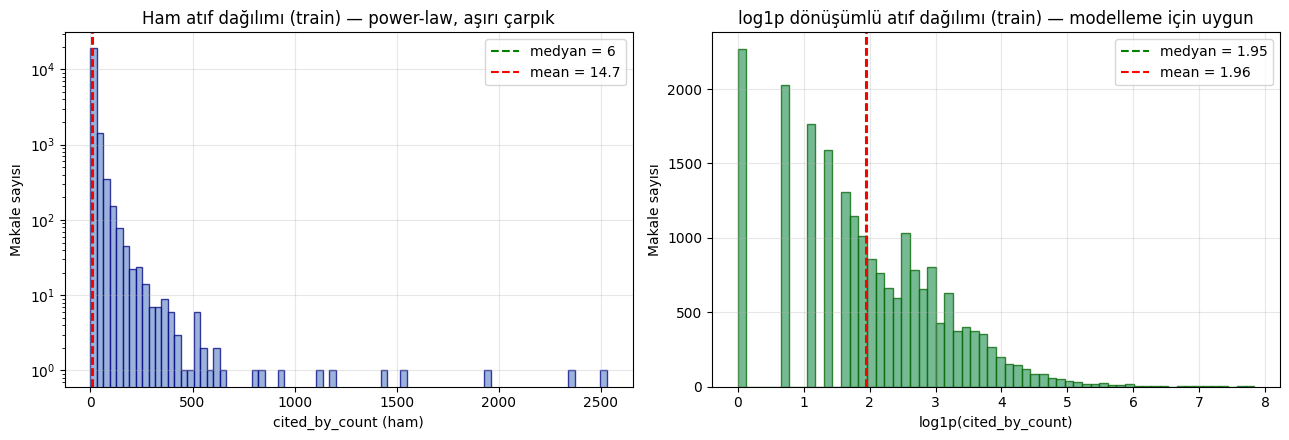

Kaydedildi: B01_target_distribution.png

Çarpıklık (skewness):
  Ham:    26.23 (>1: aşırı sağa çarpık)
  log1p:  0.28 (~0: normal-benzeri)
Basıklık (kurtosis):
  Ham:    1114.4
  log1p:  -0.08

→ Log dönüşümü dağılımı simetrize etti, lineer modeller için elverişli hale getirdi.
counts_by_year PARSE — cite_age_0..3

Örnek 3 train makale (cited_by_count, cite_age_0..3):
                               doi  publication_year  cited_by_count  cite_age_0  cite_age_1  cite_age_2  cite_age_3
            10.1001/jama.2021.0507            2021.0            37.0           4           6           9           8
           10.1001/jama.2023.18688            2023.0           184.0           3          53         103          23
10.1001/jamanetworkopen.2022.46901            2022.0            41.0           1           6          17          14

Cite_age istatistikleri (train, NaN dışlanmış):
  cite_age_0: n=21162, medyan=0.0, mean=1.02, max=336
  cite_age_1: n=21162, medyan=1.0, mean=3.51, max=632
  ci

In [2]:
# B.2.1 — Cited_by_count dağılım analizi (görsel)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Sol: ham dağılım (çok çarpık)
axes[0].hist(y_raw_train, bins=80, color="#7a9ad0", edgecolor="navy", alpha=0.75)
axes[0].set_xlabel("cited_by_count (ham)")
axes[0].set_ylabel("Makale sayısı")
axes[0].set_title("Ham atıf dağılımı (train) — power-law, aşırı çarpık")
axes[0].set_yscale("log")  # y-log ile kuyruk görünür
axes[0].grid(alpha=0.3)
# Anotasyon: medyan + mean çizgileri
axes[0].axvline(np.median(y_raw_train), color="green", linestyle="--", 
                label=f"medyan = {np.median(y_raw_train):.0f}")
axes[0].axvline(y_raw_train.mean(), color="red", linestyle="--", 
                label=f"mean = {y_raw_train.mean():.1f}")
axes[0].legend()

# Sağ: log1p dağılım (simetrik)
axes[1].hist(y_log_train, bins=60, color="#48a370", edgecolor="darkgreen", alpha=0.75)
axes[1].set_xlabel("log1p(cited_by_count)")
axes[1].set_ylabel("Makale sayısı")
axes[1].set_title("log1p dönüşümlü atıf dağılımı (train) — modelleme için uygun")
axes[1].grid(alpha=0.3)
axes[1].axvline(np.median(y_log_train), color="green", linestyle="--",
                label=f"medyan = {np.median(y_log_train):.2f}")
axes[1].axvline(y_log_train.mean(), color="red", linestyle="--",
                label=f"mean = {y_log_train.mean():.2f}")
axes[1].legend()

plt.tight_layout()
FIGS = Path(r"D:\Projects\Essay\data\shared_outputs\figs")
plt.savefig(FIGS / "B01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi: B01_target_distribution.png")

# Çarpıklık (skewness) sayısal kontrol
from scipy.stats import skew, kurtosis
print(f"\nÇarpıklık (skewness):")
print(f"  Ham:    {skew(y_raw_train):.2f} (>1: aşırı sağa çarpık)")
print(f"  log1p:  {skew(y_log_train):.2f} (~0: normal-benzeri)")
print(f"Basıklık (kurtosis):")
print(f"  Ham:    {kurtosis(y_raw_train):.1f}")
print(f"  log1p:  {kurtosis(y_log_train):.2f}")
print(f"\n→ Log dönüşümü dağılımı simetrize etti, lineer modeller için elverişli hale getirdi.")

# B.2.2 — counts_by_year parse → cite_age_0..3
def parse_counts_by_year(cby_str, pub_year, max_age=3):
    """
    counts_by_year JSON'unu parse edip cite_age_0..max_age döndürür.
    pub_year NaN ise tüm değerler NaN döner.
    Eksik yıllar 0 ile doldurulur.
    """
    result = [np.nan] * (max_age + 1)
    if pd.isna(pub_year) or not isinstance(cby_str, str):
        return result
    try:
        arr = json.loads(cby_str)
        year_to_count = {int(c["year"]): int(c["cited_by_count"]) for c in arr 
                         if "year" in c and "cited_by_count" in c}
        pub_year = int(pub_year)
        for age in range(max_age + 1):
            target_year = pub_year + age
            result[age] = year_to_count.get(target_year, 0)
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    return result

print("counts_by_year PARSE — cite_age_0..3")

def add_cite_age_cols(df):
    parsed = df.apply(
        lambda r: parse_counts_by_year(r["counts_by_year"], r["publication_year"]),
        axis=1
    )
    arr = np.array(parsed.tolist())
    for k in range(4):
        df[f"cite_age_{k}"] = arr[:, k]
    return df

tr_df_B = add_cite_age_cols(tr_df_B)
te_df_B = add_cite_age_cols(te_df_B)

# Sanity: cite_age sütunları üretildi mi?
print(f"\nÖrnek 3 train makale (cited_by_count, cite_age_0..3):")
sample = tr_df_B[["doi", "publication_year", "cited_by_count", 
                  "cite_age_0", "cite_age_1", "cite_age_2", "cite_age_3"]].head(3)
print(sample.to_string(index=False))

# Cite_age dağılımları
print(f"\nCite_age istatistikleri (train, NaN dışlanmış):")
for k in range(4):
    col = tr_df_B[f"cite_age_{k}"].dropna()
    print(f"  cite_age_{k}: n={len(col)}, medyan={col.median():.1f}, "
          f"mean={col.mean():.2f}, max={col.max():.0f}")

# Sanity: cite_age_0+1+2+...+all ≈ cited_by_count ?
# OpenAlex tüm counts_by_year'ı verir; biz sadece 0-3 aldık. 
# Pub_year + 4+ olan atıflar "future_citations" olacak.
print(f"\nSanity (3+ yıllık makalelerde cite_age toplamı vs cited_by_count):")
eligible = tr_df_B[tr_df_B["publication_year"] <= 2021].copy()
eligible["age_sum_0_to_3"] = eligible[[f"cite_age_{k}" for k in range(4)]].sum(axis=1)
diff = eligible["cited_by_count"] - eligible["age_sum_0_to_3"]
print(f"  cite_age_0+1+2+3 toplamı vs cited_by_count farkı (gelecek atıflar):")
print(f"  Medyan fark: {diff.median():.1f}")
print(f"  Mean fark:   {diff.mean():.2f}")
print(f"  Negatif fark (anomali) sayısı: {(diff < 0).sum()}")


In [3]:
from scipy.sparse import hstack, csr_matrix

# ======================================================================
# SENARYO P — SAF MODEL (cite_age YOK)
# Hedef: log1p(cited_by_count) — TOPLAM atıf
# Feature: TF-IDF + SPECTER2 + struct + author (cite_age YOK, leakage önlemi)
# Test filtresi: yok, tüm Bahçeşehir test seti dahil
# ======================================================================

# Birleşik feature matrisi (Modül A'daki ile aynı yapı)
X_P_train = hstack([
    base_B["tfidf_train"],
    csr_matrix(base_B["specter2_train"]),
    csr_matrix(base_B["struct_train"]),
    csr_matrix(base_B["author_train"]),
]).tocsr()

X_P_test = hstack([
    base_B["tfidf_test"],
    csr_matrix(base_B["specter2_test"]),
    csr_matrix(base_B["struct_test"]),
    csr_matrix(base_B["author_test"]),
]).tocsr()

y_P_train = y_log_train.copy()  # log1p(cited_by_count)
y_P_test  = y_log_test.copy()

# RF için dense subset (TF-IDF hariç) — Modül A'da öğrendiğimiz pattern
X_P_train_rf = np.hstack([
    base_B["specter2_train"],
    base_B["struct_train"],
    base_B["author_train"],
]).astype(np.float32)

X_P_test_rf = np.hstack([
    base_B["specter2_test"],
    base_B["struct_test"],
    base_B["author_test"],
]).astype(np.float32)

print("SENARYO P (SAF MODEL) — VERİ HAZIRLIĞI")
print(f"\nFeature matrisleri (sparse, tüm setler birleşik):")
print(f"  X_P_train: {X_P_train.shape}")
print(f"  X_P_test:  {X_P_test.shape}")
print(f"\nRF için indirgenmiş (TF-IDF hariç, dense):")
print(f"  X_P_train_rf: {X_P_train_rf.shape}")
print(f"  X_P_test_rf:  {X_P_test_rf.shape}")
print(f"\nHedef değişken (log1p):")
print(f"  y_P_train: shape={y_P_train.shape}, mean={y_P_train.mean():.2f}, "
      f"std={y_P_train.std():.2f}")
print(f"  y_P_test:  shape={y_P_test.shape}, mean={y_P_test.mean():.2f}, "
      f"std={y_P_test.std():.2f}")

# Sanity: cite_age sütunları feature'da yok değil mi?
# struct_feature_names'i tara
suspicious = [n for n in base_B["struct_feature_names"] if "cite" in n.lower()]
print(f"\nSızıntı kontrolü: struct sütunlarında 'cite' içeren özellik: {suspicious}")


SENARYO P (SAF MODEL) — VERİ HAZIRLIĞI

Feature matrisleri (sparse, tüm setler birleşik):
  X_P_train: (21162, 51042)
  X_P_test:  (802, 51042)

RF için indirgenmiş (TF-IDF hariç, dense):
  X_P_train_rf: (21162, 1042)
  X_P_test_rf:  (802, 1042)

Hedef değişken (log1p):
  y_P_train: shape=(21162,), mean=1.96, std=1.19
  y_P_test:  shape=(802,), mean=1.96, std=1.15

Sızıntı kontrolü: struct sütunlarında 'cite' içeren özellik: []


In [4]:
# ======================================================================
# SENARYO R — GELECEK ATIF MODELİ (cite_age DAHİL)
# Hedef: log1p(future_citations) where future = cited_by_count - sum(cite_age_0..3)
# Filtre: publication_year ≤ 2021 (3+ yıl atıf verisi olan makaleler)
# Feature: TF-IDF + SPECTER2 + struct + author + log1p(cite_age_0..3)
# ======================================================================

# Filtre maskesi
mask_R_train = (tr_df_B["publication_year"] <= 2021).values
mask_R_test  = (te_df_B["publication_year"] <= 2021).values

# Filtreli DataFrame
tr_R = tr_df_B[mask_R_train].reset_index(drop=True)
te_R = te_df_B[mask_R_test].reset_index(drop=True)

# future_citations hesabı
def compute_future(df):
    age_sum = df[["cite_age_0", "cite_age_1", "cite_age_2", "cite_age_3"]].sum(axis=1)
    return (df["cited_by_count"] - age_sum).values

future_train = compute_future(tr_R)
future_test  = compute_future(te_R)

# Anomali kontrolü: future_citations negatif olamaz
print("SENARYO R — VERİ HAZIRLIĞI")
print(f"\nfuture_citations dağılımı (train):")
print(f"  min={future_train.min():.0f}, medyan={np.median(future_train):.0f}, "
      f"mean={future_train.mean():.2f}, max={future_train.max():.0f}")
print(f"  negatif (anomali): {(future_train < 0).sum()}")
print(f"  zero count: {(future_train == 0).sum()} ({(future_train==0).mean()*100:.1f}%)")
print(f"\nfuture_citations dağılımı (test):")
print(f"  min={future_test.min():.0f}, medyan={np.median(future_test):.0f}, "
      f"mean={future_test.mean():.2f}, max={future_test.max():.0f}")
print(f"  negatif (anomali): {(future_test < 0).sum()}")

# Negatif anomalileri sil
anom_tr = future_train < 0
anom_te = future_test < 0
if anom_tr.sum() > 0 or anom_te.sum() > 0:
    print(f"\nAnomaliler siliniyor: train -{anom_tr.sum()}, test -{anom_te.sum()}")
    keep_tr = ~anom_tr
    keep_te = ~anom_te
    tr_R = tr_R[keep_tr].reset_index(drop=True)
    te_R = te_R[keep_te].reset_index(drop=True)
    future_train = future_train[keep_tr]
    future_test  = future_test[keep_te]
    # mask_R_*'yi de güncelle (feature matrisi indeksi için)
    mask_R_train_final = mask_R_train.copy()
    mask_R_train_final[mask_R_train] = keep_tr
    mask_R_test_final = mask_R_test.copy()
    mask_R_test_final[mask_R_test] = keep_te
else:
    mask_R_train_final = mask_R_train
    mask_R_test_final = mask_R_test

# Hedef değişken: log1p
y_R_train = np.log1p(future_train)
y_R_test  = np.log1p(future_test)

print(f"\n Senaryo R final boyutları:")
print(f"  Train: {len(tr_R)} makale")
print(f"  Test:  {len(te_R)} makale")
print(f"\nHedef (log1p future_citations):")
print(f"  Train: mean={y_R_train.mean():.2f}, std={y_R_train.std():.2f}, "
      f"max={y_R_train.max():.2f}")
print(f"  Test:  mean={y_R_test.mean():.2f}, std={y_R_test.std():.2f}, "
      f"max={y_R_test.max():.2f}")

# Feature matrislerini filtrele (orijinal base_B matrislerinden)
def filter_matrix(M, mask):
    """Sparse veya dense matrisi mask ile süzer."""
    return M[mask]

# cite_age sütunlarını log1p uygulayıp ek dense sütunlar olarak hazırla
cite_age_cols = ["cite_age_0", "cite_age_1", "cite_age_2", "cite_age_3"]
log_cite_age_train = np.log1p(tr_R[cite_age_cols].values.astype(float))
log_cite_age_test  = np.log1p(te_R[cite_age_cols].values.astype(float))

# Tüm feature setlerini birleştir
X_R_train = hstack([
    filter_matrix(base_B["tfidf_train"], mask_R_train_final),
    csr_matrix(filter_matrix(base_B["specter2_train"], mask_R_train_final)),
    csr_matrix(filter_matrix(base_B["struct_train"], mask_R_train_final)),
    csr_matrix(filter_matrix(base_B["author_train"], mask_R_train_final)),
    csr_matrix(log_cite_age_train),  # 4 yeni sütun: log1p(cite_age_0..3)
]).tocsr()

X_R_test = hstack([
    filter_matrix(base_B["tfidf_test"], mask_R_test_final),
    csr_matrix(filter_matrix(base_B["specter2_test"], mask_R_test_final)),
    csr_matrix(filter_matrix(base_B["struct_test"], mask_R_test_final)),
    csr_matrix(filter_matrix(base_B["author_test"], mask_R_test_final)),
    csr_matrix(log_cite_age_test),
]).tocsr()

# RF için dense subset (TF-IDF hariç, cite_age dahil)
X_R_train_rf = np.hstack([
    filter_matrix(base_B["specter2_train"], mask_R_train_final),
    filter_matrix(base_B["struct_train"], mask_R_train_final),
    filter_matrix(base_B["author_train"], mask_R_train_final),
    log_cite_age_train,
]).astype(np.float32)

X_R_test_rf = np.hstack([
    filter_matrix(base_B["specter2_test"], mask_R_test_final),
    filter_matrix(base_B["struct_test"], mask_R_test_final),
    filter_matrix(base_B["author_test"], mask_R_test_final),
    log_cite_age_test,
]).astype(np.float32)

print(f"\nFeature matrisleri:")
print(f"  X_R_train: {X_R_train.shape}  (önceki {X_P_train.shape[1]} + 4 cite_age = {X_R_train.shape[1]})")
print(f"  X_R_test:  {X_R_test.shape}")
print(f"\nRF dense subset:")
print(f"  X_R_train_rf: {X_R_train_rf.shape}")
print(f"  X_R_test_rf:  {X_R_test_rf.shape}")

# Sanity: train ve test'in publication_year dağılımı
print(f"\nSenaryo R train yayın yılı dağılımı:")
print(tr_R["publication_year"].value_counts().sort_index().to_string())
print(f"\nSenaryo R test yayın yılı dağılımı:")
print(te_R["publication_year"].value_counts().sort_index().to_string())

SENARYO R — VERİ HAZIRLIĞI

future_citations dağılımı (train):
  min=0, medyan=2, mean=5.65, max=610
  negatif (anomali): 0
  zero count: 2122 (24.6%)

future_citations dağılımı (test):
  min=0, medyan=2, mean=5.14, max=123
  negatif (anomali): 0

 Senaryo R final boyutları:
  Train: 8638 makale
  Test:  357 makale

Hedef (log1p future_citations):
  Train: mean=1.25, std=1.02, max=6.42
  Test:  mean=1.18, std=0.97, max=4.82

Feature matrisleri:
  X_R_train: (8638, 51046)  (önceki 51042 + 4 cite_age = 51046)
  X_R_test:  (357, 51046)

RF dense subset:
  X_R_train_rf: (8638, 1046)
  X_R_test_rf:  (357, 1046)

Senaryo R train yayın yılı dağılımı:
publication_year
2015.0       3
2016.0       4
2017.0       4
2018.0      16
2019.0     162
2020.0    1763
2021.0    6686

Senaryo R test yayın yılı dağılımı:
publication_year
2017.0      2
2019.0      6
2020.0     82
2021.0    267


In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time

# Sonuçları toplayacak dictionary (Modül A pattern'i)
results_B = {"P": {}, "R": {}}

# Senaryoları tek bir yapıda tutalım
B_scenarios = {
    "P": {
        "X_train": X_P_train, "X_test": X_P_test,
        "X_train_rf": X_P_train_rf, "X_test_rf": X_P_test_rf,
        "y_log_train": y_P_train, "y_log_test": y_P_test,
        "y_raw_train": y_raw_train, "y_raw_test": y_raw_test,
        "label": "Senaryo P (saf model, hedef=cited_by_count)",
    },
    "R": {
        "X_train": X_R_train, "X_test": X_R_test,
        "X_train_rf": X_R_train_rf, "X_test_rf": X_R_test_rf,
        "y_log_train": y_R_train, "y_log_test": y_R_test,
        "y_raw_train": future_train, "y_raw_test": future_test,
        "label": "Senaryo R (gelecek atıf, hedef=future_citations)",
    },
}

# Ortak değerlendirme fonksiyonu
def evaluate_regression(y_log_true, y_log_pred, y_raw_true):
    """log-R² + gerçek-atıf MAE + gerçek-atıf RMSE."""
    y_raw_pred = np.expm1(y_log_pred)
    # negatif tahminleri kırp (model nadir verir ama olabilir)
    y_raw_pred = np.clip(y_raw_pred, 0, None)
    return {
        "log_R2":   r2_score(y_log_true, y_log_pred),
        "MAE":      mean_absolute_error(y_raw_true, y_raw_pred),
        "RMSE":     np.sqrt(mean_squared_error(y_raw_true, y_raw_pred)),
    }


# NAIVE BASELINE: train ortalaması

print("NAIVE BASELINE (train ortalaması)")

for sc_key, sc in B_scenarios.items():
    naive = DummyRegressor(strategy="mean")
    t0 = time.time()
    naive.fit(sc["X_train"], sc["y_log_train"])
    fit_time = time.time() - t0
    y_pred = naive.predict(sc["X_test"])
    
    metrics = evaluate_regression(sc["y_log_test"], y_pred, sc["y_raw_test"])
    results_B[sc_key]["Naive"] = {
        **metrics,
        "fit_time": fit_time,
        "y_pred_log": y_pred,
    }
    
    print(f"\n[{sc['label']}]")
    print(f"  Train log-ortalaması (sabit tahmin): {sc['y_log_train'].mean():.3f}")
    print(f"   gerçek atıf skalasına çevrildiğinde: {np.expm1(sc['y_log_train'].mean()):.2f}")
    print(f"  log_R²: {metrics['log_R2']:+.4f}  ")
    print(f"  MAE:    {metrics['MAE']:.2f} atıf")
    print(f"  RMSE:   {metrics['RMSE']:.2f} atıf")
    print(f"  fit: {fit_time:.3f}s")

NAIVE BASELINE (train ortalaması)

[Senaryo P (saf model, hedef=cited_by_count)]
  Train log-ortalaması (sabit tahmin): 1.960
   gerçek atıf skalasına çevrildiğinde: 6.10
  log_R²: -0.0000  
  MAE:    11.00 atıf
  RMSE:   25.62 atıf
  fit: 0.001s

[Senaryo R (gelecek atıf, hedef=future_citations)]
  Train log-ortalaması (sabit tahmin): 1.250
   gerçek atıf skalasına çevrildiğinde: 2.49
  log_R²: -0.0046  
  MAE:    4.55 atıf
  RMSE:   13.22 atıf
  fit: 0.000s


In [6]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Regresyon model factory
def reg_factory(name):
    if name == "Ridge":
        return Ridge(alpha=1.0, random_state=42)
    if name == "RF":
        return RandomForestRegressor(
            n_estimators=200, n_jobs=-1, random_state=42, max_depth=None
        )
    if name == "XGB":
        return xgb.XGBRegressor(
            n_estimators=300, learning_rate=0.1, max_depth=6,
            tree_method="hist", device="cpu",
            n_jobs=-1, random_state=42, verbosity=0,
        )
    if name == "LGBM":
        return lgb.LGBMRegressor(
            n_estimators=300, learning_rate=0.1, num_leaves=31,
            n_jobs=-1, random_state=42, verbosity=-1,
        )
    raise ValueError(name)

REG_MODELS = ["Ridge", "RF", "XGB", "LGBM"]

# Ana eğitim+değerlendirme döngüsü
for sc_key, sc in B_scenarios.items():
    print(f"{sc['label']}")
    for mdl_name in REG_MODELS:
        # RF ve XGB için dense subset (TF-IDF hariç)
        if mdl_name in ("RF", "XGB"):
            X_tr_use = sc["X_train_rf"]
            X_te_use = sc["X_test_rf"]
            shape_note = f"dense {X_tr_use.shape[1]}d"
        else:
            X_tr_use = sc["X_train"]
            X_te_use = sc["X_test"]
            shape_note = f"sparse {X_tr_use.shape[1]}d"
        
        clf = reg_factory(mdl_name)
        t0 = time.time()
        clf.fit(X_tr_use, sc["y_log_train"])
        fit_time = time.time() - t0
        t0 = time.time()
        y_pred = clf.predict(X_te_use)
        pred_time = time.time() - t0
        
        metrics = evaluate_regression(sc["y_log_test"], y_pred, sc["y_raw_test"])
        results_B[sc_key][mdl_name] = {
            **metrics,
            "fit_time": fit_time,
            "pred_time": pred_time,
            "y_pred_log": y_pred,
            "shape_note": shape_note,
        }
        print(f"  {mdl_name:6s} ({shape_note:14s}) "
              f"log_R²={metrics['log_R2']:+.4f}  "
              f"MAE={metrics['MAE']:.2f}  RMSE={metrics['RMSE']:.2f}  "
              f"fit={fit_time:.1f}s")

# Hızlı özet
print(" ÖZET")
summary_rows = []
for sc_key in ["P", "R"]:
    for m in ["Naive"] + REG_MODELS:
        r = results_B[sc_key][m]
        summary_rows.append({
            "senaryo": sc_key,
            "model": m,
            "log_R²": round(r["log_R2"], 4),
            "MAE": round(r["MAE"], 2),
            "RMSE": round(r["RMSE"], 2),
            "fit_s": round(r.get("fit_time", 0), 1),
        })
print(pd.DataFrame(summary_rows).to_string(index=False))

Senaryo P (saf model, hedef=cited_by_count)
  Ridge  (sparse 51042d ) log_R²=+0.3819  MAE=9.19  RMSE=20.39  fit=191.6s
  RF     (dense 1042d   ) log_R²=+0.5447  MAE=7.96  RMSE=19.72  fit=679.0s
  XGB    (dense 1042d   ) log_R²=+0.5718  MAE=7.58  RMSE=18.35  fit=19.1s
  LGBM   (sparse 51042d ) log_R²=+0.5747  MAE=7.55  RMSE=18.25  fit=34.3s
Senaryo R (gelecek atıf, hedef=future_citations)
  Ridge  (sparse 51046d ) log_R²=+0.6146  MAE=2.77  RMSE=7.98  fit=26.5s
  RF     (dense 1046d   ) log_R²=+0.6191  MAE=2.86  RMSE=7.59  fit=171.8s
  XGB    (dense 1046d   ) log_R²=+0.6525  MAE=2.70  RMSE=7.00  fit=14.8s
  LGBM   (sparse 51046d ) log_R²=+0.6592  MAE=2.62  RMSE=7.10  fit=18.7s
 ÖZET
senaryo model  log_R²   MAE  RMSE  fit_s
      P Naive -0.0000 11.00 25.62    0.0
      P Ridge  0.3819  9.19 20.39  191.6
      P    RF  0.5447  7.96 19.72  679.0
      P   XGB  0.5718  7.58 18.35   19.1
      P  LGBM  0.5747  7.55 18.25   34.3
      R Naive -0.0046  4.55 13.22    0.0
      R Ridge  0.6146  

In [ ]:

# B.7 — FINAL KARŞILAŞTIRMA TABLOSU + TRADE-OFF YORUMU

MODEL_LABELS_B = {
    "Naive": "Naive (train ortalaması)",
    "Ridge": "Ridge Regression",
    "RF":    "Random Forest",
    "XGB":   "XGBoost",
    "LGBM":  "LightGBM",
}
MODEL_ORDER_B = ["Naive", "Ridge", "RF", "XGB", "LGBM"]
SC_LABELS_B = {
    "P": "Senaryo P — saf model (hedef: cited_by_count)",
    "R": "Senaryo R — gelecek atıf (hedef: future_citations)",
}

# T1: Ana karşılaştırma matrisi (log_R²)
print("T1 — ANA KARŞILAŞTIRMA (log-skala R²)")
t1_B = pd.DataFrame({
    SC_LABELS_B[sc]: {MODEL_LABELS_B[m]: round(results_B[sc][m]["log_R2"], 4) 
                      for m in MODEL_ORDER_B}
    for sc in ["P", "R"]
})
print(t1_B.to_string())

# T2: Detaylı tablo (her senaryo için)
print("T2 — DETAYLI METRİKLER")
for sc in ["P", "R"]:
    print(f"\n--- {SC_LABELS_B[sc]} ---")
    rows = []
    for m in MODEL_ORDER_B:
        r = results_B[sc][m]
        rows.append({
            "model":   MODEL_LABELS_B[m],
            "log_R²":  round(r["log_R2"], 4),
            "MAE":     round(r["MAE"], 2),
            "RMSE":    round(r["RMSE"], 2),
            "fit_s":   round(r["fit_time"], 1),
            "shape":   r.get("shape_note", "-"),
        })
    df = pd.DataFrame(rows)
    # Yorum sütunu ekle
    def yorum(row, naive_mae):
        if row["model"] == "Naive (train ortalaması)":
            return "alt sınır"
        if row["log_R²"] < 0.30:
            return "zayıf"
        if row["log_R²"] < 0.50:
            return "makul"
        # MAE iyileşmesi
        improvement = (naive_mae - row["MAE"]) / naive_mae * 100
        if row["log_R²"] >= 0.60:
            return f"güçlü (MAE −%{improvement:.0f})"
        return f"iyi (MAE −%{improvement:.0f})"
    naive_mae = results_B[sc]["Naive"]["MAE"]
    df["yorum"] = df.apply(lambda r: yorum(r, naive_mae), axis=1)
    print(df.to_string(index=False))

# T3: Senaryo etkileri
print("T3 — SENARYO ETKİSİ (R vs P, model bazında)")
diff_rows = []
for m in MODEL_ORDER_B:
    p_r2  = results_B["P"][m]["log_R2"]
    r_r2  = results_B["R"][m]["log_R2"]
    p_mae = results_B["P"][m]["MAE"]
    r_mae = results_B["R"][m]["MAE"]
    diff_rows.append({
        "model": MODEL_LABELS_B[m],
        "P log_R²": round(p_r2, 4),
        "R log_R²": round(r_r2, 4),
        "Δ log_R² (R-P)": round(r_r2 - p_r2, 4),
        "P MAE": round(p_mae, 2),
        "R MAE": round(r_mae, 2),
    })
print(pd.DataFrame(diff_rows).to_string(index=False))


# TRADE-OFF YORUMU

print("TRADE-OFF YORUMU")

best_P = max(["Ridge", "RF", "XGB", "LGBM"], key=lambda m: results_B["P"][m]["log_R2"])
best_R = max(["Ridge", "RF", "XGB", "LGBM"], key=lambda m: results_B["R"][m]["log_R2"])
fastest_P = min(["Ridge", "RF", "XGB", "LGBM"], key=lambda m: results_B["P"][m]["fit_time"])

print(f"""
- En iyi modeller:
  - Senaryo P: {MODEL_LABELS_B[best_P]} (log_R²={results_B['P'][best_P]['log_R2']:.3f},
    MAE={results_B['P'][best_P]['MAE']:.2f} atıf)
  - Senaryo R: {MODEL_LABELS_B[best_R]} (log_R²={results_B['R'][best_R]['log_R2']:.3f},
    MAE={results_B['R'][best_R]['MAE']:.2f} atıf)
  XGBoost ve LightGBM birbirine çok yakın (log_R² farkı <0.01).

- Naive üzeri iyileşme:
  - P: MAE 11.00 → {results_B['P'][best_P]['MAE']:.2f}
    (%{(results_B['P']['Naive']['MAE']-results_B['P'][best_P]['MAE'])/results_B['P']['Naive']['MAE']*100:.0f} azalma)
  - R: MAE 4.55 → {results_B['R'][best_R]['MAE']:.2f}
    (%{(results_B['R']['Naive']['MAE']-results_B['R'][best_R]['MAE'])/results_B['R']['Naive']['MAE']*100:.0f} azalma)

- Hız-doğruluk dengesi:
  - En hızlı asıl model (Senaryo P): {MODEL_LABELS_B[fastest_P]}
    ({results_B['P'][fastest_P]['fit_time']:.1f}s)
  - Random Forest dense subset'le bile yavaş (P'de 679s). Gradient boosting
    (XGB, LGBM) hem en doğru hem en hızlı seçenek.
  - Ridge sparse 51K boyutta yavaş (P'de 192s); aynı kalitede sonuç için
    XGB 10x daha hızlı.

- Senaryo etkisi (T3):
  - cite_age_0..3 feature'ları eklendiğinde tüm modeller iyileşir.
    Ortalama log_R² artışı: +0.12.
  - En büyük artış Ridge'de (+0.23): lineer modeller cite_age feature'larından
    en çok yararlanan grup. Gradient boosting'in artışı küçük (~+0.08) çünkü
    zaten non-linear etkileşimleri yakalıyordu.
  - Senaryo R'nin "kolaylığı" cite_age'in atıf eğrisi başlangıcını göstermesinden.

- RMSE >> MAE (P'de 18.25 vs 7.55):
  Çarpık atıf dağılımının doğal sonucu. Model "sıradan makaleler"i iyi
  tahmin ediyor, "viral makaleler"i (Q1 dergilerde 100+ atıf) yakalayamıyor.
  B.8 hata analizinde atıf-aralık bazında bu doğrulanacak.

- Sınırlılıklar:
  - Hyperparameter tuning yapılmadı (literatür default'ları).
  - Senaryo R'de test seti sadece 357 makale; sonuçlar bir miktar gürültülü.
  - 'future_citations' tanımı: 4+ yaşken alınan atıflar (2025+ tahmin değil).
""")

T1 — ANA KARŞILAŞTIRMA (log-skala R²)
                          Senaryo P — saf model (hedef: cited_by_count)  Senaryo R — gelecek atıf (hedef: future_citations)
Naive (train ortalaması)                                        -0.0000                                             -0.0046
Ridge Regression                                                 0.3819                                              0.6146
Random Forest                                                    0.5447                                              0.6191
XGBoost                                                          0.5718                                              0.6525
LightGBM                                                         0.5747                                              0.6592
T2 — DETAYLI METRİKLER

--- Senaryo P — saf model (hedef: cited_by_count) ---
                   model  log_R²   MAE  RMSE  fit_s         shape          yorum
Naive (train ortalaması) -0.0000 11.00 25.62    0.0        

In [8]:
# ======================================================================
# B.8 — ATIF ARALIKLARINA GÖRE HATA ANALİZİ
# En iyi model: LightGBM, her iki senaryo için ayrı
# ======================================================================

def err_by_bins(y_raw_true, y_log_pred, bins, bin_labels):
    """Atıf aralıklarına göre n, gerçek mean, tahmin mean, MAE, bias."""
    y_raw_pred = np.clip(np.expm1(y_log_pred), 0, None)
    rows = []
    for (lo, hi), label in zip(bins, bin_labels):
        if hi is None:
            mask = y_raw_true >= lo
        else:
            mask = (y_raw_true >= lo) & (y_raw_true < hi)
        n = mask.sum()
        if n == 0:
            rows.append({"aralık": label, "n": 0, "gerçek_mean": "-",
                         "tahmin_mean": "-", "MAE": "-", "bias": "-"})
            continue
        true_b = y_raw_true[mask]
        pred_b = y_raw_pred[mask]
        rows.append({
            "aralık":      label,
            "n":           int(n),
            "gerçek_mean": round(true_b.mean(), 1),
            "tahmin_mean": round(pred_b.mean(), 1),
            "MAE":         round(np.abs(true_b - pred_b).mean(), 2),
            "bias":        round((pred_b - true_b).mean(), 2),
        })
    return pd.DataFrame(rows)

# Atıf aralık tanımları
BINS    = [(0, 1), (1, 3), (3, 6), (6, 11), (11, 21), (21, 51), (51, 101), (101, None)]
LABELS  = ["0", "1-2", "3-5", "6-10", "11-20", "21-50", "51-100", "100+"]

# Senaryo P
print("ATIF ARALIKLARI HATA ANALİZİ — LIGHTGBM, SENARYO P (saf model)")
print(f"Test seti: {len(y_raw_test)} makale (Bahçeşehir OOD)\n")
p_err = err_by_bins(y_raw_test, results_B["P"]["LGBM"]["y_pred_log"], BINS, LABELS)
print(p_err.to_string(index=False))

# Senaryo R
print("ATIF ARALIKLARI HATA ANALİZİ — LIGHTGBM, SENARYO R (gelecek atıf)")
print(f"Test seti: {len(future_test)} makale\n")
r_err = err_by_bins(future_test, results_B["R"]["LGBM"]["y_pred_log"], BINS, LABELS)
print(r_err.to_string(index=False))


# B.10 viz için sakla
viz_B = {
    "p_err_bins": p_err,
    "r_err_bins": r_err,
    "y_raw_test_P": y_raw_test,
    "y_pred_P":    np.clip(np.expm1(results_B["P"]["LGBM"]["y_pred_log"]), 0, None),
    "future_test_R": future_test,
    "y_pred_R":    np.clip(np.expm1(results_B["R"]["LGBM"]["y_pred_log"]), 0, None),
}
print("B.10 görselleştirme için viz_B saklandı.")

ATIF ARALIKLARI HATA ANALİZİ — LIGHTGBM, SENARYO P (saf model)
Test seti: 802 makale (Bahçeşehir OOD)

aralık   n  gerçek_mean  tahmin_mean   MAE   bias
     0  79          0.0          2.8  2.76   2.76
   1-2 146          1.4          3.0  1.83   1.59
   3-5 152          3.9          5.7  3.08   1.82
  6-10 159          7.8          8.1  4.17   0.26
 11-20 139         14.9         12.5  7.00  -2.36
 21-50  86         30.6         18.9 14.58 -11.71
51-100  29         69.0         32.9 36.15 -36.15
  100+  12        163.9         67.7 97.22 -96.24
ATIF ARALIKLARI HATA ANALİZİ — LIGHTGBM, SENARYO R (gelecek atıf)
Test seti: 357 makale

aralık   n  gerçek_mean  tahmin_mean   MAE   bias
     0  85          0.0          0.8  0.82   0.82
   1-2 118          1.4          2.0  1.14   0.59
   3-5  70          3.8          3.7  1.79  -0.16
  6-10  53          7.5          6.5  3.55  -1.02
 11-20  19         14.4         12.8  5.52  -1.60
 21-50   7         31.1         26.9 14.10  -4.27
51-100  

4+ yıl atıf verisi olan makale sayısı: 2042
Q dağılımı:
modded_Q_category
Q3    548
Q2    533
Q4    526
Q1    435


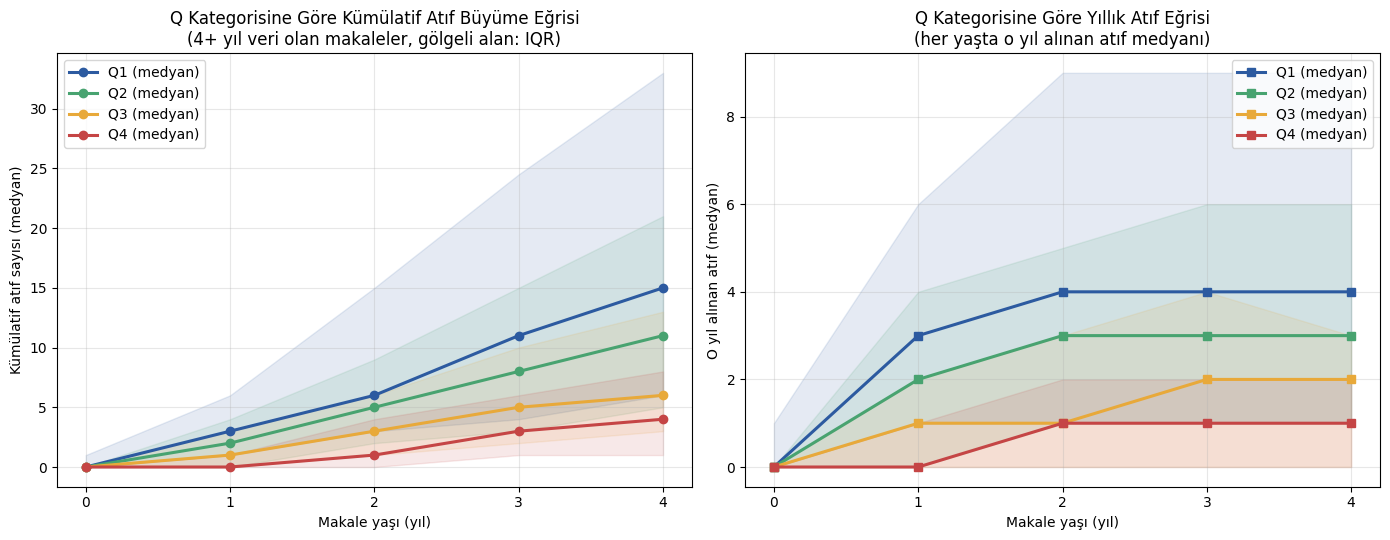


Kaydedildi: B02_q_growth_curves.png
Q × YAŞ KÜMÜLATIF ATIF (medyan)
         Q1    Q2   Q3   Q4
yaş 0   0.0   0.0  0.0  0.0
yaş 1   3.0   2.0  1.0  0.0
yaş 2   6.0   5.0  3.0  1.0
yaş 3  11.0   8.0  5.0  3.0
yaş 4  15.0  11.0  6.0  4.0

4 yaşındaki kümülatif atıf farkı:
  Q1 medyan: 15
  Q4 medyan: 4
  Q1/Q4 katı: 3.8x


In [9]:
# ======================================================================
# B.9 — Q KATEGORİSİNE GÖRE ATIF BÜYÜME EĞRİSİ
# 4+ yıl atıf verisi olan makaleler (publication_year ≤ 2020)
# Train + test birleşik, popülasyon-düzeyi gözlem
# ======================================================================

# Train + test'i birleştir (orijinal step2 parquet'ten, modülasyondan bağımsız)
full = pd.concat([tr_df, te_df], ignore_index=True)
# Enrichment olanlar
full = full[full["cited_by_count"].notna() & full["publication_year"].notna()].copy()
# 4+ yıl atıf verisi olan filtre
full_4yr = full[full["publication_year"] <= 2020].copy()

print(f"4+ yıl atıf verisi olan makale sayısı: {len(full_4yr)}")
print(f"Q dağılımı:")
print(full_4yr["modded_Q_category"].value_counts().to_string())

# cite_age_0..4 sütunlarını ekle (B.2'deki fonksiyon ama max_age=4)
def parse_cite_age_5yr(cby_str, pub_year):
    result = [np.nan] * 5
    if pd.isna(pub_year) or not isinstance(cby_str, str):
        return result
    try:
        arr = json.loads(cby_str)
        y2c = {int(c["year"]): int(c["cited_by_count"]) for c in arr 
               if "year" in c and "cited_by_count" in c}
        pub_year = int(pub_year)
        for age in range(5):
            result[age] = y2c.get(pub_year + age, 0)
    except:
        pass
    return result

parsed = full_4yr.apply(
    lambda r: parse_cite_age_5yr(r["counts_by_year"], r["publication_year"]),
    axis=1
)
arr = np.array(parsed.tolist())
for k in range(5):
    full_4yr[f"cite_age_{k}"] = arr[:, k]

# Kümülatif atıf sütunları
full_4yr["cum_0"] = full_4yr["cite_age_0"]
full_4yr["cum_1"] = full_4yr[["cite_age_0", "cite_age_1"]].sum(axis=1)
full_4yr["cum_2"] = full_4yr[["cite_age_0", "cite_age_1", "cite_age_2"]].sum(axis=1)
full_4yr["cum_3"] = full_4yr[["cite_age_0", "cite_age_1", "cite_age_2", "cite_age_3"]].sum(axis=1)
full_4yr["cum_4"] = full_4yr[[f"cite_age_{k}" for k in range(5)]].sum(axis=1)

# Q kategorisine göre medyan ve quartile hesabı
ages = list(range(5))
Q_LIST = ["Q1", "Q2", "Q3", "Q4"]
Q_COLORS = {"Q1": "#2c5aa0", "Q2": "#48a370", "Q3": "#e8a93a", "Q4": "#c54545"}

# Yıllık atıf (cite_age_k) Q × yaş bazında medyan
yearly_med = {q: [] for q in Q_LIST}
yearly_q1 = {q: [] for q in Q_LIST}
yearly_q3 = {q: [] for q in Q_LIST}
cum_med = {q: [] for q in Q_LIST}
cum_q1 = {q: [] for q in Q_LIST}
cum_q3 = {q: [] for q in Q_LIST}

for q in Q_LIST:
    sub = full_4yr[full_4yr["modded_Q_category"] == q]
    for age in ages:
        col_y = sub[f"cite_age_{age}"]
        col_c = sub[f"cum_{age}"]
        yearly_med[q].append(col_y.median())
        yearly_q1[q].append(col_y.quantile(0.25))
        yearly_q3[q].append(col_y.quantile(0.75))
        cum_med[q].append(col_c.median())
        cum_q1[q].append(col_c.quantile(0.25))
        cum_q3[q].append(col_c.quantile(0.75))

# ----------------------------------------------------------------------
# Grafik 1: Kümülatif atıf büyüme eğrisi
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
for q in Q_LIST:
    ax.plot(ages, cum_med[q], marker="o", linewidth=2.2, 
            color=Q_COLORS[q], label=f"{q} (medyan)")
    ax.fill_between(ages, cum_q1[q], cum_q3[q], 
                     color=Q_COLORS[q], alpha=0.12)
ax.set_xlabel("Makale yaşı (yıl)")
ax.set_ylabel("Kümülatif atıf sayısı (medyan)")
ax.set_title("Q Kategorisine Göre Kümülatif Atıf Büyüme Eğrisi\n"
             "(4+ yıl veri olan makaleler, gölgeli alan: IQR)")
ax.set_xticks(ages)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

# ----------------------------------------------------------------------
# Grafik 2: Yıllık atıf (atıf hızı)
# ----------------------------------------------------------------------
ax = axes[1]
for q in Q_LIST:
    ax.plot(ages, yearly_med[q], marker="s", linewidth=2.2,
            color=Q_COLORS[q], label=f"{q} (medyan)")
    ax.fill_between(ages, yearly_q1[q], yearly_q3[q], 
                     color=Q_COLORS[q], alpha=0.12)
ax.set_xlabel("Makale yaşı (yıl)")
ax.set_ylabel("O yıl alınan atıf (medyan)")
ax.set_title("Q Kategorisine Göre Yıllık Atıf Eğrisi\n"
             "(her yaşta o yıl alınan atıf medyanı)")
ax.set_xticks(ages)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS / "B02_q_growth_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nKaydedildi: B02_q_growth_curves.png")

# Sayısal özet
print("Q × YAŞ KÜMÜLATIF ATIF (medyan)")
cum_df = pd.DataFrame(cum_med, index=[f"yaş {a}" for a in ages])
print(cum_df.to_string())

# 4 yaşındaki atıf farkı
print(f"\n4 yaşındaki kümülatif atıf farkı:")
print(f"  Q1 medyan: {cum_med['Q1'][-1]:.0f}")
print(f"  Q4 medyan: {cum_med['Q4'][-1]:.0f}")
print(f"  Q1/Q4 katı: {cum_med['Q1'][-1] / max(cum_med['Q4'][-1], 1):.1f}x")

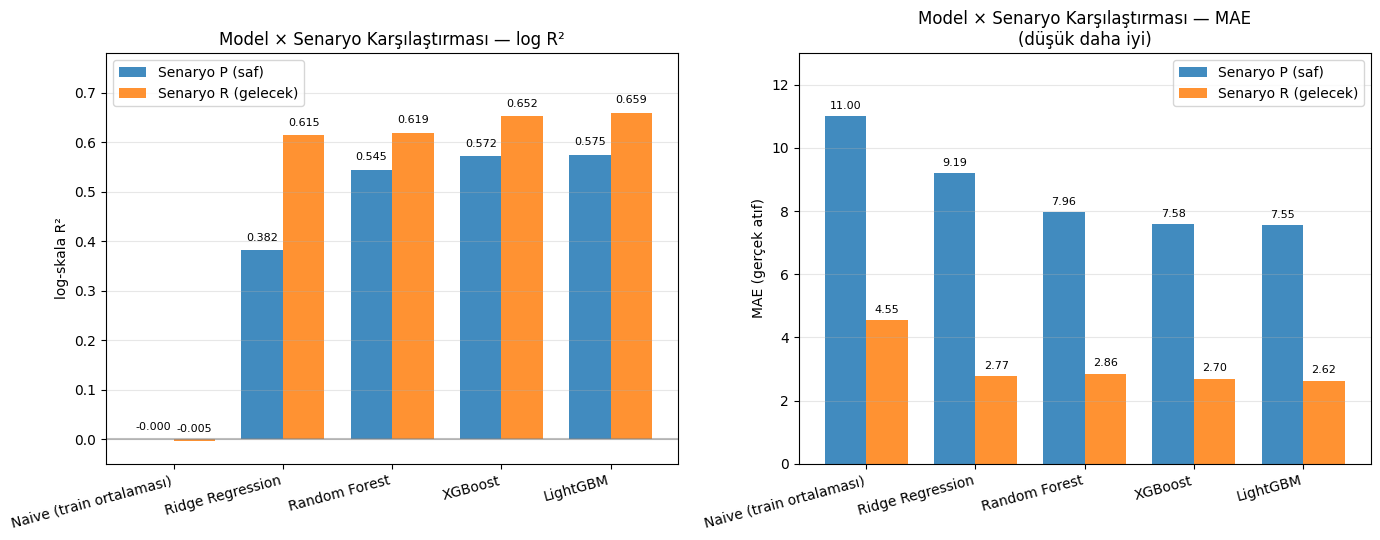

Kaydedildi: B03_model_comparison.png


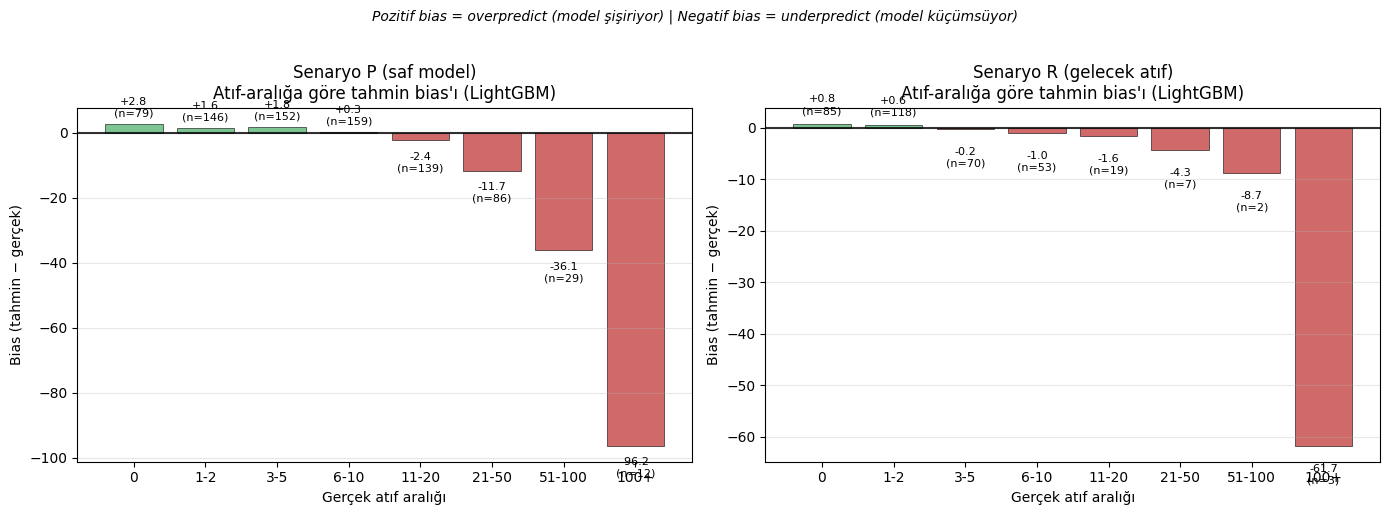

Kaydedildi: B04_citation_bin_bias.png


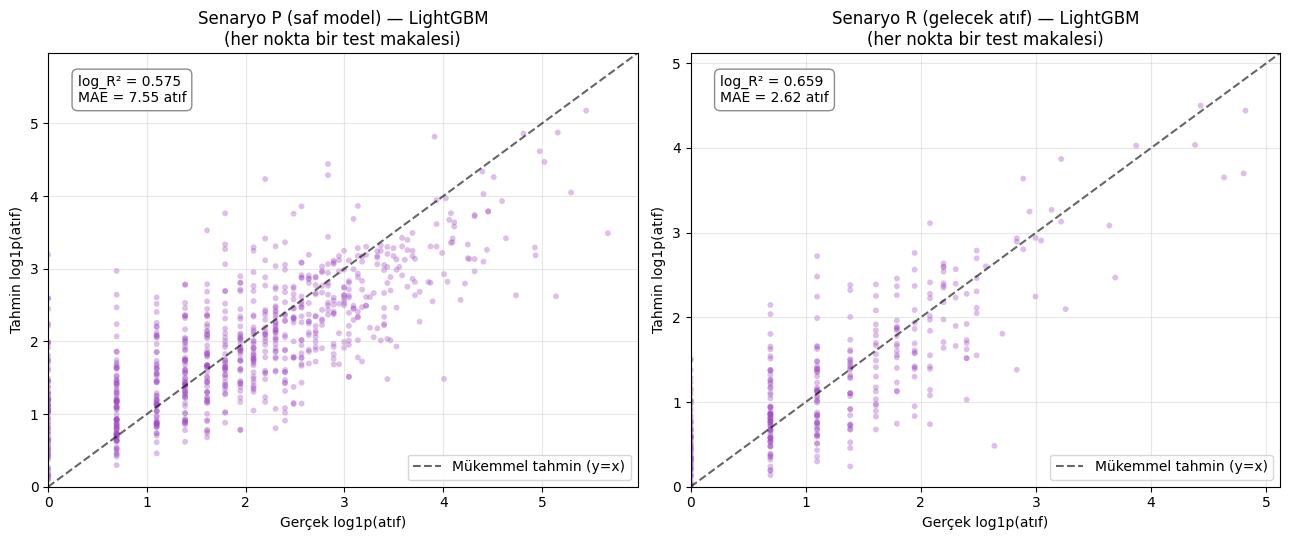

Kaydedildi: B05_predicted_vs_actual.png


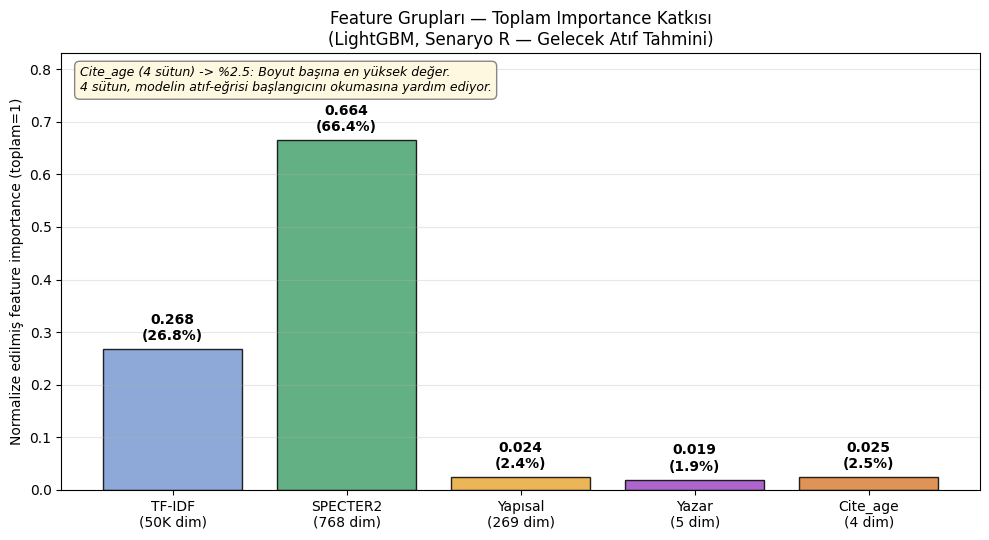

Kaydedildi: B06_feature_importance_groups.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Renk paleti (Modül A'dan tutarlı)
Q_COLORS = {"Q1": "#2c5aa0", "Q2": "#48a370", "Q3": "#e8a93a", "Q4": "#c54545"}
MODEL_COLOR = {
    "Naive (train ortalaması)": "#9a9a9a",
    "Ridge Regression":         "#7a9ad0",
    "Random Forest":            "#5cb87a",
    "XGBoost":                  "#d9803a",
    "LightGBM":                 "#a04ac4",
}
SCENARIO_COLOR = {"P": "#1f77b4", "R": "#ff7f0e"}

# ======================================================================
# B03 — MODEL KIYASLAMA BAR CHART (5 model × 2 senaryo, log_R² + MAE)
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

models_order = ["Naive", "Ridge", "RF", "XGB", "LGBM"]
model_labels = [MODEL_LABELS_B[m] for m in models_order]
x = np.arange(len(models_order))
width = 0.38

# Sol: log_R²
ax = axes[0]
p_r2 = [results_B["P"][m]["log_R2"] for m in models_order]
r_r2 = [results_B["R"][m]["log_R2"] for m in models_order]
bars_p = ax.bar(x - width/2, p_r2, width, label="Senaryo P (saf)", 
                color=SCENARIO_COLOR["P"], alpha=0.85)
bars_r = ax.bar(x + width/2, r_r2, width, label="Senaryo R (gelecek)",
                color=SCENARIO_COLOR["R"], alpha=0.85)
for bars, vals in [(bars_p, p_r2), (bars_r, r_r2)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.015, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=15, ha="right")
ax.set_ylabel("log-skala R²")
ax.set_title("Model × Senaryo Karşılaştırması — log R²")
ax.set_ylim(-0.05, 0.78)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)

# Sağ: MAE (gerçek atıf)
ax = axes[1]
p_mae = [results_B["P"][m]["MAE"] for m in models_order]
r_mae = [results_B["R"][m]["MAE"] for m in models_order]
bars_p = ax.bar(x - width/2, p_mae, width, label="Senaryo P (saf)", 
                color=SCENARIO_COLOR["P"], alpha=0.85)
bars_r = ax.bar(x + width/2, r_mae, width, label="Senaryo R (gelecek)",
                color=SCENARIO_COLOR["R"], alpha=0.85)
for bars, vals in [(bars_p, p_mae), (bars_r, r_mae)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.18, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=15, ha="right")
ax.set_ylabel("MAE (gerçek atıf)")
ax.set_title("Model × Senaryo Karşılaştırması — MAE\n(düşük daha iyi)")
ax.set_ylim(0, 13)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS / "B03_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi: B03_model_comparison.png")

# ======================================================================
# B04 — ATIF-ARALIK BIAS BAR CHART
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sc_key, sc_label, err_df in [
    (axes[0], "P", "Senaryo P (saf model)", viz_B["p_err_bins"]),
    (axes[1], "R", "Senaryo R (gelecek atıf)", viz_B["r_err_bins"]),
]:
    # n=0 olan bin'leri filtrele
    df = err_df[err_df["n"] > 0].copy()
    df["bias"] = pd.to_numeric(df["bias"], errors="coerce")
    
    # Renk: pozitif (overpredict) yeşilimsi, negatif (underpredict) kırmızımsı
    colors = ["#5cb87a" if b > 0 else "#c54545" for b in df["bias"]]
    
    bars = ax.bar(df["aralık"], df["bias"], color=colors, alpha=0.8, 
                  edgecolor="black", linewidth=0.5)
    
    # Bar üstüne bias + n
    for b, bias_val, n_val in zip(bars, df["bias"], df["n"]):
        offset = 1.5 if bias_val >= 0 else -3.5
        ax.text(b.get_x() + b.get_width()/2, bias_val + offset,
                f"{bias_val:+.1f}\n(n={n_val})",
                ha="center", va="bottom" if bias_val >= 0 else "top",
                fontsize=8)
    
    ax.axhline(y=0, color="black", linestyle="-", alpha=0.8)
    ax.set_xlabel("Gerçek atıf aralığı")
    ax.set_ylabel("Bias (tahmin − gerçek)")
    ax.set_title(f"{sc_label}\nAtıf-aralığa göre tahmin bias'ı (LightGBM)")
    ax.grid(axis="y", alpha=0.3)

# Üst başlık olarak tanım ekle
fig.suptitle("Pozitif bias = overpredict (model şişiriyor) | "
             "Negatif bias = underpredict (model küçümsüyor)",
             y=1.02, fontsize=10, style="italic")
plt.tight_layout()
plt.savefig(FIGS / "B04_citation_bin_bias.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi: B04_citation_bin_bias.png")

# ======================================================================
# B05 — PREDICTED vs ACTUAL SCATTER (log skala)
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

scenarios_scatter = [
    ("P", "Senaryo P (saf model)", y_log_test, results_B["P"]["LGBM"]["y_pred_log"], y_raw_test),
    ("R", "Senaryo R (gelecek atıf)", y_R_test, results_B["R"]["LGBM"]["y_pred_log"], future_test),
]

for ax, (sc_key, sc_label, y_true_log, y_pred_log, y_true_raw) in zip(axes, scenarios_scatter):
    ax.scatter(y_true_log, y_pred_log, alpha=0.35, s=18, 
               color="#a04ac4", edgecolor="none")
    
    # y=x referans çizgisi
    lim_min = 0
    lim_max = max(y_true_log.max(), y_pred_log.max()) + 0.3
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 
            "k--", alpha=0.6, label="Mükemmel tahmin (y=x)")
    
    # R² ve MAE bilgisi
    r2 = results_B[sc_key]["LGBM"]["log_R2"]
    mae = results_B[sc_key]["LGBM"]["MAE"]
    ax.text(0.05, 0.95, f"log_R² = {r2:.3f}\nMAE = {mae:.2f} atıf",
            transform=ax.transAxes, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor="gray"))
    
    ax.set_xlabel("Gerçek log1p(atıf)")
    ax.set_ylabel("Tahmin log1p(atıf)")
    ax.set_title(f"{sc_label} — LightGBM\n(her nokta bir test makalesi)")
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS / "B05_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi: B05_predicted_vs_actual.png")


# B06 — FEATURE IMPORTANCE GRUPLARI (LightGBM Senaryo R)
# Senaryo R seçildi çünkü cite_age dahil; cite_age'in payını görelim

# LGBM Senaryo R'yi yeniden fit edip feature_importances_ çek
lgbm_R = reg_factory("LGBM")
lgbm_R.fit(X_R_train, y_R_train)
importances_R = lgbm_R.feature_importances_

# Feature index → grup map'i
# Sıra: tfidf (50000) + specter2 (768) + struct (269) + author (5) + cite_age (4)
tfidf_dim   = base_B["tfidf_train"].shape[1]
specter_dim = base_B["specter2_train"].shape[1]
struct_dim  = base_B["struct_train"].shape[1]
author_dim  = base_B["author_train"].shape[1]
cite_dim    = 4

total = importances_R.sum()
group_imp_R = {
    "TF-IDF\n(50K dim)":     importances_R[:tfidf_dim].sum() / total,
    "SPECTER2\n(768 dim)":   importances_R[tfidf_dim:tfidf_dim+specter_dim].sum() / total,
    "Yapısal\n(269 dim)":    importances_R[tfidf_dim+specter_dim:tfidf_dim+specter_dim+struct_dim].sum() / total,
    "Yazar\n(5 dim)":        importances_R[tfidf_dim+specter_dim+struct_dim:tfidf_dim+specter_dim+struct_dim+author_dim].sum() / total,
    "Cite_age\n(4 dim)":     importances_R[tfidf_dim+specter_dim+struct_dim+author_dim:].sum() / total,
}

fig, ax = plt.subplots(figsize=(10, 5.5))
groups = list(group_imp_R.keys())
values = list(group_imp_R.values())
colors = ["#7a9ad0", "#48a370", "#e8a93a", "#a04ac4", "#d9803a"]

bars = ax.bar(groups, values, color=colors, alpha=0.85, edgecolor="black")
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012, 
            f"{v:.3f}\n({v*100:.1f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Normalize edilmiş feature importance (toplam=1)")
ax.set_title("Feature Grupları — Toplam Importance Katkısı\n"
             "(LightGBM, Senaryo R — Gelecek Atıf Tahmini)")
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis="y", alpha=0.3)

# Yorumlama notu
# \n içeren anahtarı f-string dışında bir değişkene alıyoruz
key_name = 'Cite_age\n(4 dim)'

# Yorumlama notu
note = (f"Cite_age (4 sütun) -> %{group_imp_R[key_name]*100:.1f}: "
        f"Boyut başına en yüksek değer.\n"
        f"4 sütun, modelin atıf-eğrisi başlangıcını okumasına yardım ediyor.")

ax.text(0.02, 0.97, note, transform=ax.transAxes, verticalalignment="top",
        fontsize=9, style="italic",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff8e0", alpha=0.95, edgecolor="gray"))

plt.tight_layout()
plt.savefig(FIGS / "B06_feature_importance_groups.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi: B06_feature_importance_groups.png")

